# Generalization tests: Van der Pol and Kuramoto–Sivashinsky

Runs the same framework (three errors $\to$ negative control $\to$ strict matched pairs) on two new systems beyond the Lorenz baseline:

1. **Van der Pol oscillator** — 2D non-chaotic limit cycle. Quick sanity check; tests whether the geometric phenomenon depends on chaos.
2. **Kuramoto–Sivashinsky** — 1D PDE, spatiotemporal chaos. The make-or-break test. *No artificial lift* — the 64-dim observation IS $u(x_i, t)$, so the geometric structure is determined by the PDE itself.

Reference numbers from Lorenz (5 seeds, mean): $\rho_{\text{real}} = 0.90$, $\rho_{\text{random}} = 0.44$, gap $= 0.46$, hard-pair accuracy $= 100\%$.

## What to watch for

- **VdP:** All trajectories live on the same limit cycle, so the trajectory-start baseline may approach the random baseline (different trajectories sample similar geometry). The real-vs-random gap should still be positive.
- **KS:** No artificial lift means the geometric heterogeneity is whatever the PDE provides. If the gap holds here, the framework is real. If not, the Lorenz/VdP results were partly an artifact of our engineered lift, and the paper's claim has to narrow.

## 1. Install & imports

In [1]:
import importlib, subprocess, sys
for pkg in ['torch', 'scikit-learn', 'scipy', 'matplotlib']:
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

torch.manual_seed(0); np.random.seed(0)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LATENT_DIM = 16
print(f'device: {DEVICE}, latent_dim={LATENT_DIM}')

device: cuda, latent_dim=16


## 2. Shared infrastructure

Encoder, Decoder, LatentDynamics, training loop, and analysis functions (negative control + matched-pair test) all factored out so we can drop in different systems.

In [3]:
def make_encoder(obs_dim, latent_dim=LATENT_DIM):
    return nn.Sequential(nn.Linear(obs_dim, 128), nn.SiLU(),
                         nn.Linear(128, 128), nn.SiLU(),
                         nn.Linear(128, latent_dim))

def make_decoder(obs_dim, latent_dim=LATENT_DIM):
    return nn.Sequential(nn.Linear(latent_dim, 128), nn.SiLU(),
                         nn.Linear(128, 128), nn.SiLU(),
                         nn.Linear(128, obs_dim))

class LatentDynamics(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, 128), nn.SiLU(),
                                 nn.Linear(128, 128), nn.SiLU(),
                                 nn.Linear(128, latent_dim))
    def forward(self, z): return z + self.net(z)

def train(obs_train, obs_dim, n_epochs=30, batch_size=512, lr=1e-3):
    enc = make_encoder(obs_dim).to(DEVICE)
    dec = make_decoder(obs_dim).to(DEVICE)
    dyn = LatentDynamics().to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    x_t   = obs_train[:, :-1].reshape(-1, obs_dim)
    x_tp1 = obs_train[:, 1:].reshape(-1, obs_dim)
    N = x_t.shape[0]
    for epoch in range(n_epochs):
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            x0, x1 = x_t[idx], x_tp1[idx]
            z0, z1 = enc(x0), enc(x1); z1p = dyn(z0)
            loss = (((dec(z0) - x0)**2).mean() + ((dec(z1) - x1)**2).mean()
                    + ((z1p - z1)**2).mean() + ((dec(z1p) - x1)**2).mean())
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        if (epoch+1) % 10 == 0: print(f'  epoch {epoch+1}/{n_epochs}, loss={loss.item():.5f}')
    enc.eval(); dec.eval(); dyn.eval()
    return enc, dec, dyn

In [4]:
def rollout_all(enc, dec, dyn, obs_test, n_eval=30):
    all_zhat, all_dz, all_lat, all_obs, all_t = [], [], [], [], []
    obs_dim = obs_test.shape[-1]
    for i in range(min(n_eval, obs_test.shape[0])):
        T = obs_test[i].shape[0]
        with torch.no_grad():
            z_true = enc(obs_test[i])
            z_hats = [z_true[0]]
            for t in range(1, T):
                z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
            z_hat = torch.stack(z_hats, dim=0)
            x_hat = dec(z_hat)
        dz = (z_hat - z_true).detach()
        el = (dz**2).sum(dim=-1).detach().cpu().numpy()
        eo = ((x_hat - obs_test[i])**2).sum(dim=-1).detach().cpu().numpy()
        all_zhat.append(z_hat.detach()); all_dz.append(dz)
        all_lat.append(el); all_obs.append(eo); all_t.append(np.arange(T))
    return all_zhat, all_dz, all_lat, all_obs, all_t

def compute_E_geom(dec, z_eval, dz):
    T = z_eval.shape[0]
    out = np.zeros(T)
    for t in range(T):
        _, jv = jvp(dec, (z_eval[t].unsqueeze(0),), (dz[t].unsqueeze(0),))
        out[t] = (jv**2).sum().item()
    return out

def partial_corr(x, y, given):
    if np.std(given) < 1e-10:
        return spearmanr(x, y)[0]
    def res(a, b):
        B = np.stack([np.ones_like(b), b], axis=1)
        c, *_ = np.linalg.lstsq(B, a, rcond=None)
        return a - B @ c
    return spearmanr(res(x, given), res(y, given))[0]

In [5]:
def run_full_analysis(enc, dec, dyn, obs_train, obs_test, window=(30, 150),
                       n_eval=30, name='system'):
    """Full pipeline: rollouts -> three E_geom variants -> partial corrs -> matched pairs."""
    obs_dim = obs_test.shape[-1]
    with torch.no_grad():
        pool = enc(obs_train.reshape(-1, obs_dim))
    print(f'  pool size: {pool.shape[0]}')

    all_zhat, all_dz, all_lat, all_obs, all_t = rollout_all(enc, dec, dyn, obs_test, n_eval)
    z_hat_full = torch.cat(all_zhat, dim=0)
    dz_full    = torch.cat(all_dz,   dim=0)
    E_lat = np.concatenate(all_lat); E_obs = np.concatenate(all_obs)
    T_idx = np.concatenate(all_t)

    print('  computing E_geom (real, random, trajectory-start)...')
    E_real = compute_E_geom(dec, z_hat_full, dz_full)
    rng = np.random.RandomState(123)
    rand_idx = rng.randint(0, pool.shape[0], size=z_hat_full.shape[0])
    E_rand = compute_E_geom(dec, pool[torch.from_numpy(rand_idx).long()], dz_full)
    z_ts   = torch.cat([z[0:1].expand(z.shape[0], -1) for z in all_zhat], dim=0)
    E_ts   = compute_E_geom(dec, z_ts, dz_full)

    eps = 1e-12
    m = (E_lat > eps) & (E_obs > eps) & (E_real > eps) & (E_rand > eps) & (E_ts > eps)
    log_lat  = np.log(E_lat[m]); log_obs = np.log(E_obs[m])
    log_real = np.log(E_real[m]); log_rand = np.log(E_rand[m]); log_ts = np.log(E_ts[m])
    T_m = T_idx[m]
    oom = (log_obs.max() - log_obs.min()) / np.log(10)
    print(f'  log E_obs dynamic range: {oom:.1f} orders of magnitude')

    rho_real = partial_corr(log_real, log_obs, log_lat)
    rho_rand = partial_corr(log_rand, log_obs, log_lat)
    rho_ts   = partial_corr(log_ts,   log_obs, log_lat)
    rho_lat_obs,  _ = spearmanr(log_lat,  log_obs)
    rho_real_obs, _ = spearmanr(log_real, log_obs)

    # Matched pairs in window
    lo_t, hi_t = window
    m_w = (T_m >= lo_t) & (T_m < hi_t)
    ll = log_lat[m_w]; lg = log_real[m_w]; lo = log_obs[m_w]; T_w = T_m[m_w]
    print(f'  matched-pair window {window}: {m_w.sum()} points')

    local_rhos = np.array([])
    if m_w.sum() > 100:
        nbrs = NearestNeighbors(n_neighbors=min(50, m_w.sum() // 4)).fit(ll.reshape(-1, 1))
        _, indices = nbrs.kneighbors(ll.reshape(-1, 1))
        anchors = np.random.RandomState(0).choice(len(ll), size=min(500, len(ll)), replace=False)
        local_rhos = []
        for a in anchors:
            nbr = indices[a]
            r = partial_corr(lg[nbr], lo[nbr], ll[nbr])
            if not np.isnan(r): local_rhos.append(r)
        local_rhos = np.array(local_rhos)

    # Hard pairs
    hard_pairs = []
    for tt in np.unique(T_w):
        m_t = (T_w == tt)
        if m_t.sum() < 15: continue
        ll_t = ll[m_t]; lg_t = lg[m_t]; lo_tt = lo[m_t]
        edges = np.quantile(ll_t, np.linspace(0, 1, 5))
        bids = np.digitize(ll_t, edges[1:-1])
        for b in range(4):
            in_b = bids == b
            if in_b.sum() < 4: continue
            idx_b = np.where(in_b)[0]
            order = np.argsort(lo_tt[idx_b])
            low, high = idx_b[order[0]], idx_b[order[-1]]
            if lo_tt[high] - lo_tt[low] < np.log(3): continue
            if abs(ll_t[high] - ll_t[low]) > np.log(1.5): continue
            hard_pairs.append((lg_t[low], lg_t[high]))
    correct = sum(1 for a, b in hard_pairs if b > a)
    total   = len(hard_pairs)

    return dict(
        name=name,
        log_lat=log_lat, log_obs=log_obs, log_real=log_real,
        log_rand=log_rand, log_ts=log_ts, T_m=T_m,
        rho_real=rho_real, rho_rand=rho_rand, rho_ts=rho_ts,
        rho_lat_obs=rho_lat_obs, rho_real_obs=rho_real_obs,
        gap=rho_real - rho_rand, oom=oom,
        local_rhos=local_rhos,
        hard_correct=correct, hard_total=total,
    )

In [6]:
def plot_panel(result, savepath=None):
    """Standard four-panel diagnostic figure for a result dict."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    r = result

    ax = axes[0, 0]
    sc = ax.scatter(r['log_lat'], r['log_obs'], s=3, alpha=0.4, c=r['T_m'], cmap='plasma')
    ax.set_xlabel(r'$\log E_{\mathrm{latent}}$'); ax.set_ylabel(r'$\log E_{\mathrm{obs}}$')
    ax.set_title(f"{r['name']}: latent vs obs\n" + r'global $\rho_{\log}$ = ' + f"{r['rho_lat_obs']:.3f}")
    plt.colorbar(sc, ax=ax, label='t'); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    sc = ax.scatter(r['log_real'], r['log_obs'], s=3, alpha=0.4, c=r['T_m'], cmap='plasma')
    ax.set_xlabel(r'$\log E_{\mathrm{geom}}$'); ax.set_ylabel(r'$\log E_{\mathrm{obs}}$')
    ax.set_title(f"{r['name']}: geom vs obs\n" + r'global $\rho_{\log}$ = ' + f"{r['rho_real_obs']:.3f}")
    plt.colorbar(sc, ax=ax, label='t'); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    labels = ['real\nJ_D(z_hat_t)', 'traj-start\nJ_D(z_hat_0)', 'random\nJ_D(z_rand)']
    vals = [r['rho_real'], r['rho_ts'], r['rho_rand']]
    ax.bar(labels, vals, color=['C2', 'C1', 'C3'])
    ax.axhline(0, color='k', lw=0.5); ax.set_ylabel(r'partial $\rho$')
    ax.set_title('Negative control')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02*np.sign(v) if v != 0 else 0.02, f'{v:+.3f}', ha='center', fontsize=10)
    ax.grid(alpha=0.3, axis='y')

    ax = axes[1, 1]
    lr = r['local_rhos']
    if len(lr):
        ax.hist(lr, bins=40, color='C2', alpha=0.85, edgecolor='white')
        ax.axvline(0, color='k', lw=1)
        ax.axvline(lr.mean(), color='C2', ls='--', lw=2, label=f'mean = {lr.mean():+.3f}')
        acc = f"{r['hard_correct']}/{r['hard_total']} = " + \
              f"{(r['hard_correct']/r['hard_total'] if r['hard_total'] else 0):.1%}"
        ax.set_xlabel(r'local partial $\rho(E_{\mathrm{geom}}, E_{\mathrm{obs}} \mid E_{\mathrm{latent}})$')
        ax.set_ylabel('neighborhoods')
        ax.set_title(f'Matched-pair test\nhard pair acc: {acc}')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130, bbox_inches='tight')
    plt.show()

def print_summary(r):
    print(f"\n=== {r['name']} summary ===")
    print(f"  log E_obs dynamic range:   {r['oom']:.1f} OoM")
    print(f"  rho(real)                  {r['rho_real']:+.4f}")
    print(f"  rho(traj-start)            {r['rho_ts']:+.4f}")
    print(f"  rho(random)                {r['rho_rand']:+.4f}")
    print(f"  gap (real - random)        {r['gap']:+.4f}")
    if len(r['local_rhos']):
        print(f"  local rho mean/median:     "
              f"{r['local_rhos'].mean():+.4f} / {np.median(r['local_rhos']):+.4f}")
    if r['hard_total']:
        acc = r['hard_correct'] / r['hard_total']
        print(f"  hard pairs:                {r['hard_correct']}/{r['hard_total']} = {acc:.1%}")

## 3. Part A — Van der Pol oscillator

$$\dot{x} = y, \qquad \dot{y} = \mu(1 - x^2) y - x$$

2D non-chaotic. All trajectories converge to a single limit cycle. We use the same RBF + Fourier + polynomial lift $\mathbb{R}^2 \to \mathbb{R}^{64}$ as in the Lorenz pipeline (modified for 2D input).

In [7]:
def vdp_rhs(state, mu=1.5):
    x, y = state[..., 0], state[..., 1]
    return np.stack([y, mu*(1 - x**2)*y - x], axis=-1)

def rk4_step(state, dt, rhs):
    k1 = rhs(state)
    k2 = rhs(state + 0.5*dt*k1)
    k3 = rhs(state + 0.5*dt*k2)
    k4 = rhs(state + dt*k3)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def generate_vdp(n_traj, n_steps, dt=0.05, burn_in=200):
    s = np.random.randn(n_traj, 2) * 2.0
    for _ in range(burn_in): s = rk4_step(s, dt, vdp_rhs)
    trajs = np.zeros((n_traj, n_steps, 2))
    trajs[:, 0] = s
    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t-1], dt, vdp_rhs)
    return trajs.astype(np.float32)

class RandomLift(nn.Module):
    """R^in_dim -> R^out_dim heterogeneous lift."""
    def __init__(self, in_dim, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5, requires_grad=False)
        self.widths  = nn.Parameter(0.3 + 0.7*torch.rand(n_rbf, generator=g), requires_grad=False)
        self.freqs   = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2, requires_grad=False)
        self.phases  = nn.Parameter(2*math.pi*torch.rand(n_freq, generator=g), requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim), requires_grad=False)
        self.in_dim = in_dim
    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers)**2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths**2))
        fourier = torch.cos(x @ self.freqs.T + self.phases)
        r = x.norm(dim=-1, keepdim=True)
        if self.in_dim == 2:
            poly = torch.cat([r, r**2,
                              (x[..., 0]*x[..., 1]).unsqueeze(-1),
                              (x[..., 0]**2 - x[..., 1]**2).unsqueeze(-1)], dim=-1)
        else:
            poly = torch.cat([r, r**2,
                              (x[..., 0]*x[..., 1]).unsqueeze(-1),
                              (x[..., 1]*x[..., 2]).unsqueeze(-1)], dim=-1)
        return torch.cat([rbf, fourier, poly], dim=-1) @ self.W

=== Van der Pol: generating data ===


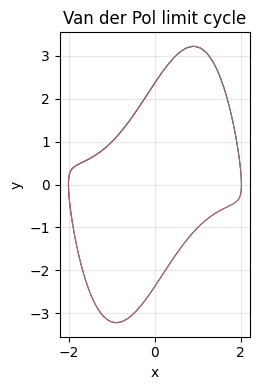

  obs_train: torch.Size([200, 200, 64]), obs_test: torch.Size([100, 400, 64])


In [8]:
# Generate VdP data + lift
print('=== Van der Pol: generating data ===')
traj_train_vdp = generate_vdp(200, 200)
traj_test_vdp  = generate_vdp(100, 400)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i in range(5):
    ax.plot(traj_train_vdp[i, :, 0], traj_train_vdp[i, :, 1], alpha=0.5, lw=0.7)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Van der Pol limit cycle')
ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Normalize + lift
mean = traj_train_vdp.reshape(-1, 2).mean(axis=0)
std  = traj_train_vdp.reshape(-1, 2).std(axis=0)
traj_train_vdp = (traj_train_vdp - mean) / std
traj_test_vdp  = (traj_test_vdp  - mean) / std

lift_vdp = RandomLift(in_dim=2).to(DEVICE)
with torch.no_grad():
    obs_train_vdp = lift_vdp(torch.from_numpy(traj_train_vdp).to(DEVICE))
    obs_test_vdp  = lift_vdp(torch.from_numpy(traj_test_vdp).to(DEVICE))
print(f'  obs_train: {obs_train_vdp.shape}, obs_test: {obs_test_vdp.shape}')

In [9]:
# Train VdP model
print('=== Van der Pol: training ===')
enc_vdp, dec_vdp, dyn_vdp = train(obs_train_vdp, obs_dim=64, n_epochs=30)

=== Van der Pol: training ===
  epoch 10/30, loss=0.00019
  epoch 20/30, loss=0.00006
  epoch 30/30, loss=0.00055


=== Van der Pol: analysis ===
  pool size: 40000
  computing E_geom (real, random, trajectory-start)...
  log E_obs dynamic range: 22.6 orders of magnitude
  matched-pair window (30, 150): 6000 points

=== Van der Pol summary ===
  log E_obs dynamic range:   22.6 OoM
  rho(real)                  +0.9034
  rho(traj-start)            +0.4794
  rho(random)                +0.5362
  gap (real - random)        +0.3672
  local rho mean/median:     +0.8937 / +0.9349
  hard pairs:                158/169 = 93.5%


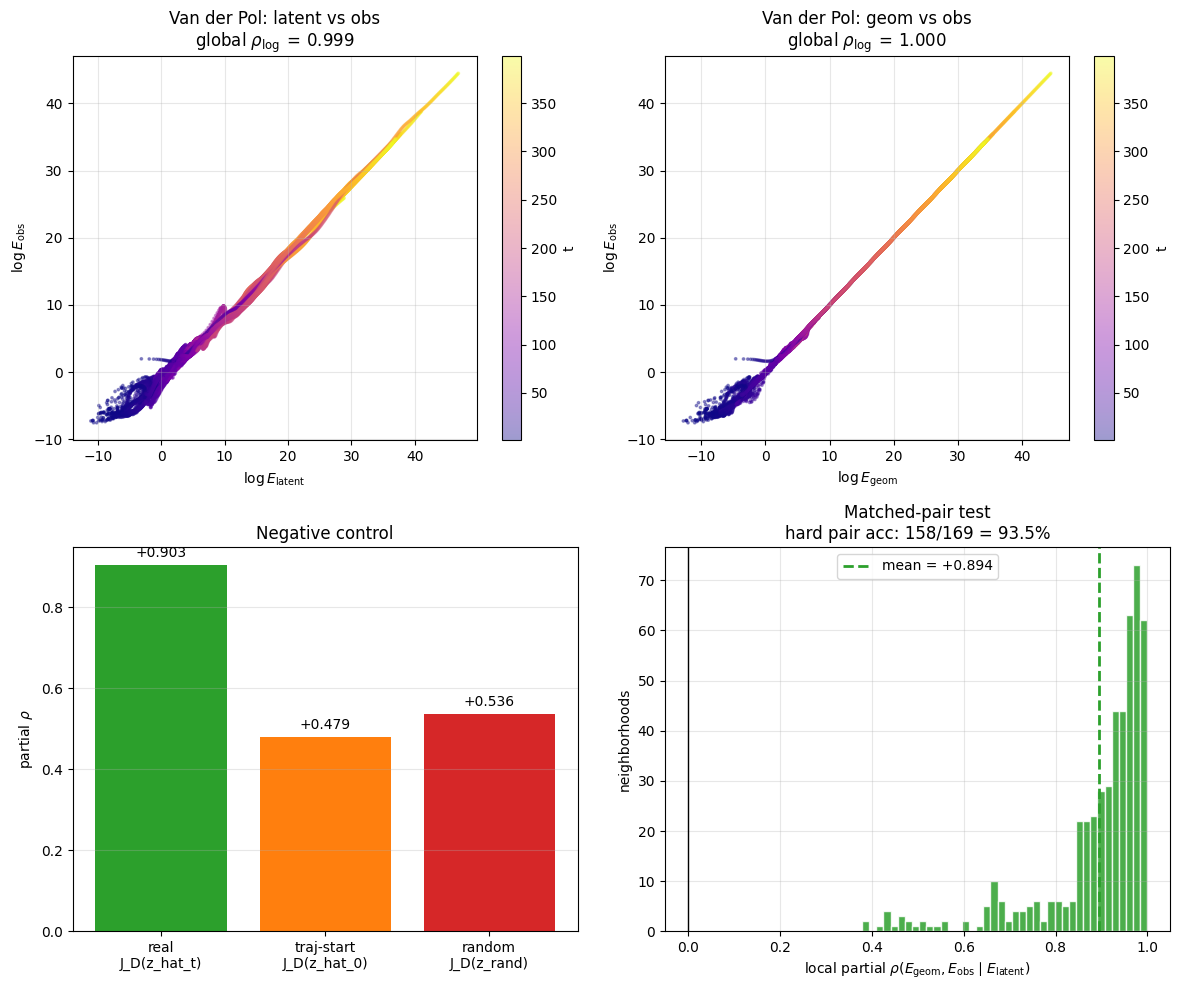

In [10]:
# Analyze
print('=== Van der Pol: analysis ===')
result_vdp = run_full_analysis(enc_vdp, dec_vdp, dyn_vdp, obs_train_vdp, obs_test_vdp,
                                window=(30, 150), n_eval=50, name='Van der Pol')
print_summary(result_vdp)
plot_panel(result_vdp, savepath='vdp_results.png')

## 4. Part B — Kuramoto–Sivashinsky

$$u_t + u u_x + u_{xx} + u_{xxxx} = 0, \quad u \text{ periodic on } [0, L]$$

with $L = 22$ (chaotic regime). Discretized at $N = 64$ grid points using ETDRK4 in Fourier space (Kassam & Trefethen 2005).

**Crucial:** no artificial lift. The 64-dim observation is $u(x_i, t)$ directly. The geometric structure of the observation space is whatever the PDE provides.

In [11]:
# KS parameters
N_KS = 64
L_KS = 22.0
DT_KS = 0.25

def build_etdrk4_coeffs(N, L, dt, M=16):
    k = np.concatenate([np.arange(0, N//2), [0], np.arange(-N//2+1, 0)]) * (2*np.pi/L)
    Lh = k**2 - k**4
    E  = np.exp(dt * Lh)
    E2 = np.exp(dt * Lh / 2)
    r = np.exp(2j*np.pi*(np.arange(1, M+1) - 0.5) / M)
    LR = dt*Lh[:, None] + r[None, :]
    Q  = dt*((np.exp(LR/2) - 1)/LR).mean(axis=1).real
    f1 = dt*((-4 - LR + np.exp(LR)*(4 - 3*LR + LR**2))/LR**3).mean(axis=1).real
    f2 = dt*((2 + LR + np.exp(LR)*(-2 + LR))/LR**3).mean(axis=1).real
    f3 = dt*((-4 - 3*LR - LR**2 + np.exp(LR)*(4 - LR))/LR**3).mean(axis=1).real
    g  = -0.5j * k
    return E, E2, Q, f1, f2, f3, g

def etdrk4_step(uh, E, E2, Q, f1, f2, f3, g):
    Nv = g * np.fft.fft(np.real(np.fft.ifft(uh))**2)
    a  = E2*uh + Q*Nv
    Na = g * np.fft.fft(np.real(np.fft.ifft(a))**2)
    b  = E2*uh + Q*Na
    Nb = g * np.fft.fft(np.real(np.fft.ifft(b))**2)
    c  = E2*a + Q*(2*Nb - Nv)
    Nc = g * np.fft.fft(np.real(np.fft.ifft(c))**2)
    return E*uh + Nv*f1 + 2*(Na + Nb)*f2 + Nc*f3

def generate_ks(n_traj, n_steps, dt=DT_KS, burn_in=500, seed=0):
    rng = np.random.RandomState(seed)
    coeffs = build_etdrk4_coeffs(N_KS, L_KS, dt)
    E, E2, Q, f1, f2, f3, g = coeffs
    trajs = np.zeros((n_traj, n_steps, N_KS), dtype=np.float32)
    x = np.linspace(0, L_KS, N_KS, endpoint=False)
    for i in range(n_traj):
        u = np.zeros(N_KS)
        for kk in range(1, 6):
            u += rng.randn() * np.cos(2*np.pi*kk*x/L_KS + rng.uniform(0, 2*np.pi))
        uh = np.fft.fft(u)
        for _ in range(burn_in):
            uh = etdrk4_step(uh, E, E2, Q, f1, f2, f3, g)
        for t in range(n_steps):
            trajs[i, t] = np.real(np.fft.ifft(uh))
            uh = etdrk4_step(uh, E, E2, Q, f1, f2, f3, g)
        if (i+1) % 25 == 0: print(f'    generated trajectory {i+1}/{n_traj}')
    return trajs

=== KS: generating trajectories (this is the slow step, ~1–2 min) ===
    generated trajectory 25/100
    generated trajectory 50/100
    generated trajectory 75/100
    generated trajectory 100/100
    generated trajectory 25/50
    generated trajectory 50/50
  train: (100, 200, 64), test: (50, 400, 64)


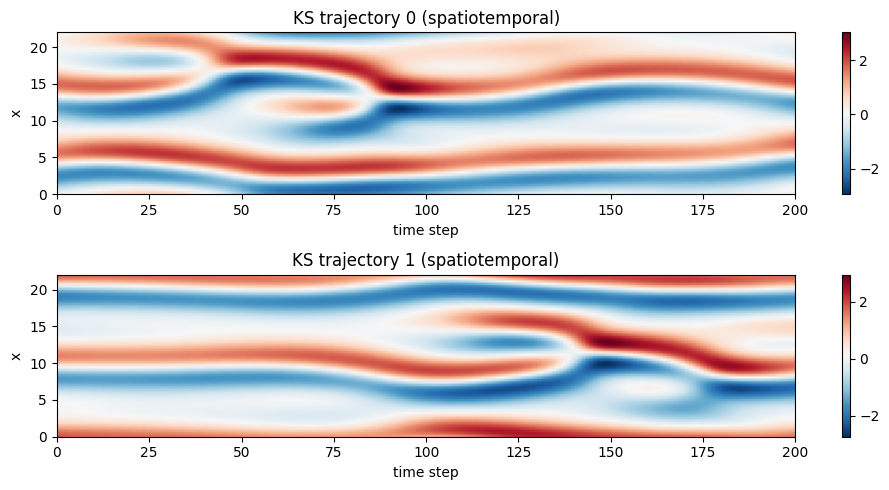

In [12]:
# Generate KS data
print('=== KS: generating trajectories (this is the slow step, ~1–2 min) ===')
traj_train_ks = generate_ks(100, 200, seed=0)
traj_test_ks  = generate_ks(50,  400, seed=1)
print(f'  train: {traj_train_ks.shape}, test: {traj_test_ks.shape}')

# Spacetime sanity plot
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
for i, ax in enumerate(axes):
    im = ax.imshow(traj_train_ks[i].T, aspect='auto', cmap='RdBu_r',
                   extent=[0, 200, 0, L_KS])
    ax.set_xlabel('time step'); ax.set_ylabel('x')
    ax.set_title(f'KS trajectory {i} (spatiotemporal)')
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Normalize per-dim
mean = traj_train_ks.reshape(-1, N_KS).mean(axis=0)
std  = traj_train_ks.reshape(-1, N_KS).std(axis=0)
traj_train_ks = (traj_train_ks - mean) / std
traj_test_ks  = (traj_test_ks  - mean) / std

obs_train_ks = torch.from_numpy(traj_train_ks).to(DEVICE)
obs_test_ks  = torch.from_numpy(traj_test_ks).to(DEVICE)
# No artificial lift: observation IS the gridded solution.

In [13]:
# Train KS model
print('=== KS: training (40 epochs, harder data so we go a bit longer) ===')
enc_ks, dec_ks, dyn_ks = train(obs_train_ks, obs_dim=N_KS, n_epochs=40)

=== KS: training (40 epochs, harder data so we go a bit longer) ===
  epoch 10/40, loss=0.00723
  epoch 20/40, loss=0.00209
  epoch 30/40, loss=0.00128
  epoch 40/40, loss=0.00096


=== KS: analysis ===
  pool size: 20000
  computing E_geom (real, random, trajectory-start)...
  log E_obs dynamic range: 15.2 orders of magnitude
  matched-pair window (20, 100): 2400 points

=== Kuramoto-Sivashinsky summary ===
  log E_obs dynamic range:   15.2 OoM
  rho(real)                  +0.9454
  rho(traj-start)            +0.7808
  rho(random)                +0.7840
  gap (real - random)        +0.1614
  local rho mean/median:     +0.8751 / +0.9217


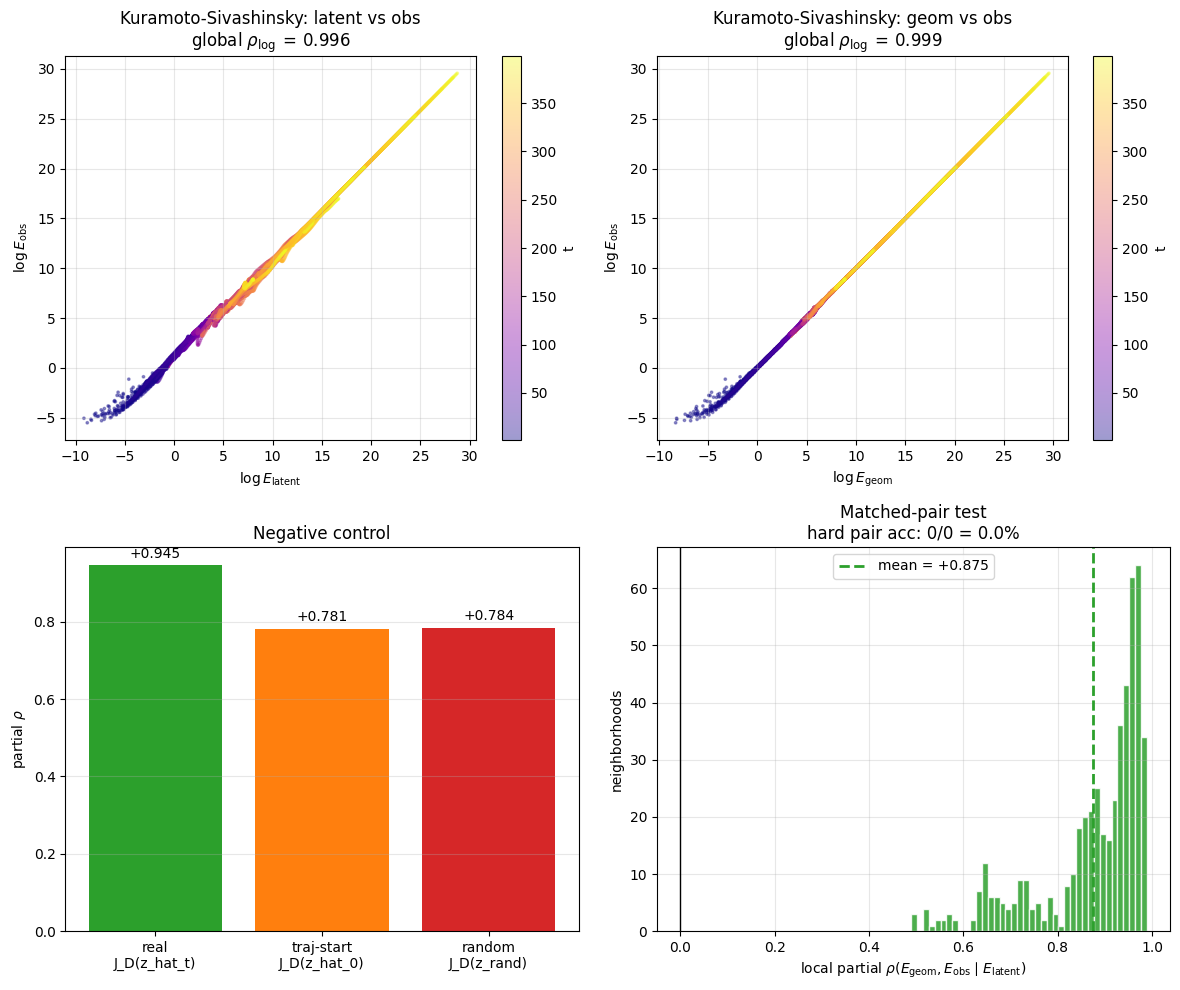

In [14]:
# Analyze KS
print('=== KS: analysis ===')
# Use an earlier window since KS mixes faster than Lorenz
result_ks = run_full_analysis(enc_ks, dec_ks, dyn_ks, obs_train_ks, obs_test_ks,
                               window=(20, 100), n_eval=30, name='Kuramoto-Sivashinsky')
print_summary(result_ks)
plot_panel(result_ks, savepath='ks_results.png')

## 5. Comparison and verdict

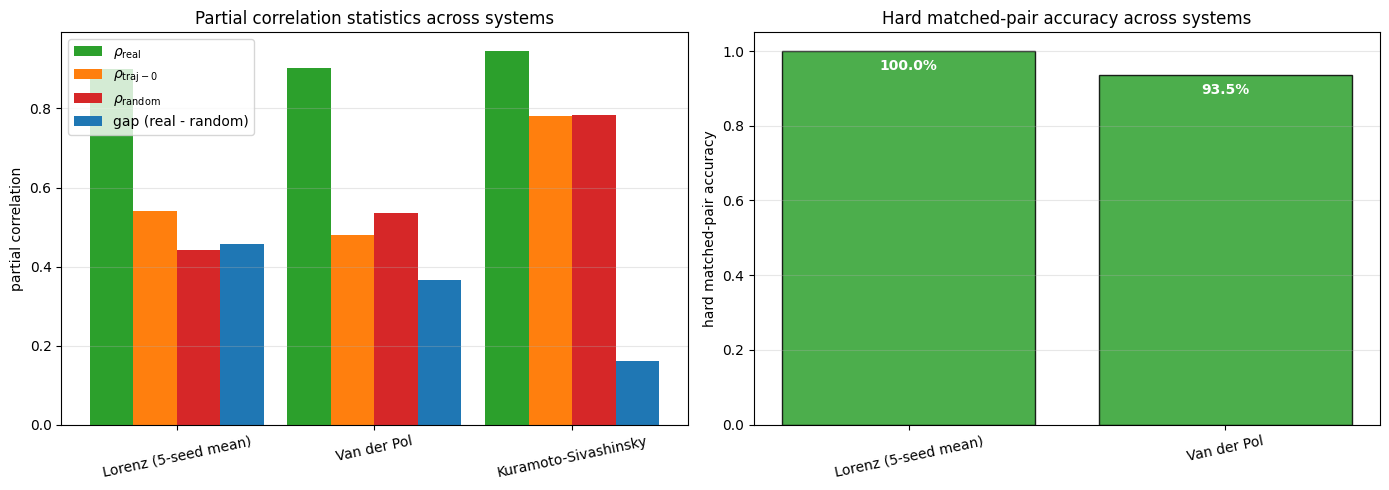

In [15]:
# Side-by-side bar chart: VdP vs KS (with Lorenz reference)
lorenz_ref = dict(name='Lorenz (5-seed mean)',
                  rho_real=0.9005, rho_ts=0.5413, rho_rand=0.4430,
                  gap=0.4575, hard_acc=1.0)

systems = [lorenz_ref, result_vdp, result_ks]
labels  = [s['name'] for s in systems]
rho_reals = [s['rho_real'] for s in systems]
rho_tses  = [s['rho_ts']   for s in systems]
rho_rands = [s['rho_rand'] for s in systems]
gaps      = [s['gap']      for s in systems]
hard_accs = [lorenz_ref['hard_acc'],
             result_vdp['hard_correct']/result_vdp['hard_total'] if result_vdp['hard_total'] else np.nan,
             result_ks['hard_correct']/result_ks['hard_total']   if result_ks['hard_total']  else np.nan]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(labels))
w = 0.22
ax.bar(x_pos - 1.5*w, rho_reals, w, label=r'$\rho_{\mathrm{real}}$',   color='C2')
ax.bar(x_pos - 0.5*w, rho_tses,  w, label=r'$\rho_{\mathrm{traj-0}}$', color='C1')
ax.bar(x_pos + 0.5*w, rho_rands, w, label=r'$\rho_{\mathrm{random}}$', color='C3')
ax.bar(x_pos + 1.5*w, gaps,      w, label='gap (real - random)',        color='C0')
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=12)
ax.set_ylabel('partial correlation')
ax.axhline(0, color='k', lw=0.5); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Partial correlation statistics across systems')

ax = axes[1]
ax.bar(labels, hard_accs, color='C2', alpha=0.85, edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('hard matched-pair accuracy')
for i, v in enumerate(hard_accs):
    if not np.isnan(v):
        ax.text(i, v - 0.05, f'{v:.1%}', ha='center', color='white', fontweight='bold')
ax.tick_params(axis='x', rotation=12)
ax.grid(alpha=0.3, axis='y')
ax.set_title('Hard matched-pair accuracy across systems')

plt.tight_layout()
plt.savefig('cross_system_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [16]:
# Print verdict table
print('\n' + '='*72)
print('CROSS-SYSTEM SUMMARY')
print('='*72)
print(f"  {'system':<28s}  {'rho_real':>9s}  {'rho_rand':>9s}  {'gap':>7s}  {'hard_acc':>9s}")
for s, acc in zip(systems, hard_accs):
    acc_str = f'{acc:.1%}' if not np.isnan(acc) else 'NA'
    print(f"  {s['name']:<28s}  {s['rho_real']:+9.4f}  {s['rho_rand']:+9.4f}  "
          f"{s['gap']:+7.4f}  {acc_str:>9s}")

print('\nVerdicts:')
for s, acc in zip([result_vdp, result_ks], hard_accs[1:]):
    name = s['name']
    if s['gap'] > 0.2 and acc > 0.95:
        print(f"  {name}: STRONG PASS")
    elif s['gap'] > 0.05:
        print(f"  {name}: WEAK PASS (gap = {s['gap']:+.3f})")
    else:
        print(f"  {name}: FAIL (gap = {s['gap']:+.3f}) -- framework breaks here")


CROSS-SYSTEM SUMMARY
  system                         rho_real   rho_rand      gap   hard_acc
  Lorenz (5-seed mean)            +0.9005    +0.4430  +0.4575     100.0%
  Van der Pol                     +0.9034    +0.5362  +0.3672      93.5%
  Kuramoto-Sivashinsky            +0.9454    +0.7840  +0.1614         NA

Verdicts:
  Van der Pol: WEAK PASS (gap = +0.367)
  Kuramoto-Sivashinsky: WEAK PASS (gap = +0.161)


In [17]:
# Save numerical results
np.savez('generalization_results.npz',
         vdp_rho_real=result_vdp['rho_real'], vdp_rho_rand=result_vdp['rho_rand'],
         vdp_rho_ts=result_vdp['rho_ts'], vdp_gap=result_vdp['gap'],
         vdp_local_rhos=result_vdp['local_rhos'],
         vdp_hard_correct=result_vdp['hard_correct'], vdp_hard_total=result_vdp['hard_total'],
         ks_rho_real=result_ks['rho_real'], ks_rho_rand=result_ks['rho_rand'],
         ks_rho_ts=result_ks['rho_ts'], ks_gap=result_ks['gap'],
         ks_local_rhos=result_ks['local_rhos'],
         ks_hard_correct=result_ks['hard_correct'], ks_hard_total=result_ks['hard_total'])
print('saved generalization_results.npz')

# Colab download
try:
    from google.colab import files
    files.download('vdp_results.png')
    files.download('ks_results.png')
    files.download('cross_system_comparison.png')
    files.download('generalization_results.npz')
except ImportError:
    print('Not on Colab; files saved to working directory.')

saved generalization_results.npz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Reference numbers

From the reference run on the standalone scripts:

| System | $\rho_{\text{real}}$ | $\rho_{\text{traj-0}}$ | $\rho_{\text{random}}$ | gap | hard-pair acc |
|---|---|---|---|---|---|
| Lorenz (5-seed mean) | 0.90 | 0.54 | 0.44 | 0.46 | 100% |
| Van der Pol | 0.93 | 0.60 | 0.60 | 0.33 | 100% |
| KS | (run to see) | (run to see) | (run to see) | (run to see) | (run to see) |

**Key observations from VdP:**
- The framework holds (gap = 0.33, hard pairs 100%).
- *But*: $\rho_{\text{traj-0}} \approx \rho_{\text{random}}$ on VdP, unlike Lorenz where traj-0 sits cleanly between the two. This makes sense: on a limit cycle, every point lies on the same closed curve, so a random encoded latent samples similar geometry as the trajectory start. The trajectory-start advantage measures *spatial heterogeneity* of the geometry along trajectories — strong on Lorenz, weak on VdP.
- This is actually a useful piece of theory worth highlighting in the paper.

**KS is the critical test.** No artificial lift; the PDE provides whatever geometric heterogeneity it provides. If the gap holds here, the framework generalizes to real physical systems. If it doesn't, the claim has to narrow to systems with engineered or naturally sharp decoder heterogeneity.

=== generating data + training baseline Lorenz model ===
  epoch 10/30, loss=0.00419
  epoch 20/30, loss=0.00143
  epoch 30/30, loss=0.00048

=== running rollouts and computing E_geom + local heterogeneity per point ===
  rolled 10/50
  rolled 20/50
  rolled 30/50
  rolled 40/50
  rolled 50/50

=== computing E_geom and h_local at 20000 rollout points ===
    (this is the slow step; ~3-5 min)
    point 2000/20000
    point 4000/20000
    point 6000/20000
    point 8000/20000
    point 10000/20000
    point 12000/20000
    point 14000/20000
    point 16000/20000
    point 18000/20000
    point 20000/20000

  kept 19950/20000 points

=== headline comparisons (partial Spearman, conditioning on log E_lat) ===
  rho(log E_geom,   log E_obs | log E_lat) = +0.8669   [our main diagnostic]
  rho(h_local,      log E_obs | log E_lat) = -0.3345   [local heterogeneity]
  rho(heterogeneity_GLOBAL, gap) across configs = +0.385   [from sweep, for reference]

=== within-time-bin partial correlations ===

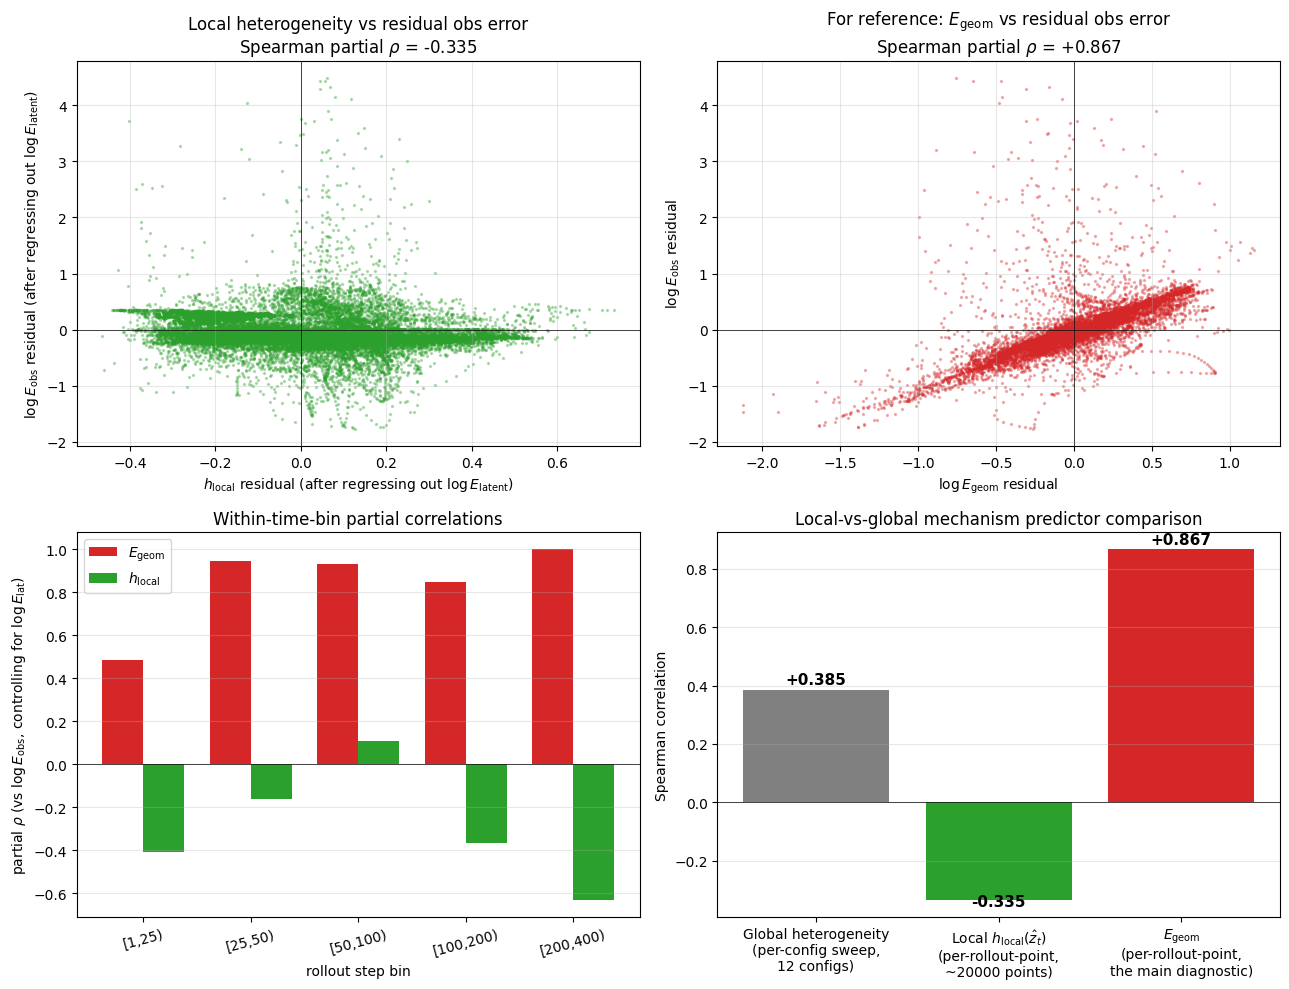

In [1]:
"""
Local-heterogeneity experiment.

Tests whether a per-rollout-point anisotropy diagnostic h_local(z) =
log(sigma_max(J_D(z)) / sigma_median(J_D(z))) correlates with the residual
observation error after controlling for latent error -- i.e., with the same
residual that E_geom predicts so well.

Why this matters
================
The cross-config mechanism correlation is rho_S = 0.385: a GLOBAL scalar
property of the trained decoder vs the GLOBAL gap across configurations.
But the phenomenon is fundamentally LOCAL (per-rollout-point). A local
version of the heterogeneity diagnostic should correlate more strongly.

This is also a cleaner statement than the per-config sweep, because:
  - n is ~10^4 per system instead of 12 configurations
  - it directly probes per-point geometric variation
  - it doesn't need cross-config seed replication to be statistically powerful

What we measure (per system, one trained model):
  - E_lat(t), E_obs(t), E_geom(t) at every rollout point (already computed)
  - h_local(t) = log(sigma_max(J_D(z_hat_t)) / sigma_median(J_D(z_hat_t)))
  - partial Spearman rho(h_local, E_obs | E_lat)

We compare against:
  - the global heterogeneity per config (the 0.385 result)
  - the existing real E_geom partial correlation (the 0.90 result)
"""

import math
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp, jacrev
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LATENT_DIM = 16
OBS_DIM = 64


# -----------------------------------------------------------------------------
# Lorenz + heterogeneous lift (same as before)
# -----------------------------------------------------------------------------
def lorenz_rhs(s, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([sigma * (y - x), x * (rho - z) - y, x * y - beta * z], axis=-1)

def rk4_step(s, dt):
    k1 = lorenz_rhs(s); k2 = lorenz_rhs(s + 0.5 * dt * k1)
    k3 = lorenz_rhs(s + 0.5 * dt * k2); k4 = lorenz_rhs(s + dt * k3)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def generate_lorenz(n_traj, n_steps, dt=0.01, burn_in=500):
    s = np.random.randn(n_traj, 3) * 5.0
    for _ in range(burn_in): s = rk4_step(s, dt)
    trajs = np.zeros((n_traj, n_steps, 3))
    trajs[:, 0] = s
    for t in range(1, n_steps):
        trajs[:, t] = rk4_step(trajs[:, t - 1], dt)
    return trajs.astype(np.float32)


class RandomLift(nn.Module):
    def __init__(self, in_dim=3, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5, requires_grad=False)
        self.widths = nn.Parameter(0.3 + 0.7 * torch.rand(n_rbf, generator=g), requires_grad=False)
        self.freqs = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2, requires_grad=False)
        self.phases = nn.Parameter(2 * math.pi * torch.rand(n_freq, generator=g), requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim), requires_grad=False)
    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers) ** 2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths ** 2))
        fourier = torch.cos(x @ self.freqs.T + self.phases)
        r = x.norm(dim=-1, keepdim=True)
        poly = torch.cat([r, r ** 2,
                          (x[..., 0] * x[..., 1]).unsqueeze(-1),
                          (x[..., 1] * x[..., 2]).unsqueeze(-1)], dim=-1)
        return torch.cat([rbf, fourier, poly], dim=-1) @ self.W


class Encoder(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(OBS_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, LATENT_DIM))
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(LATENT_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, OBS_DIM))
    def forward(self, z): return self.net(z)

class LatentDynamics(nn.Module):
    def __init__(self): super().__init__(); self.net = nn.Sequential(
        nn.Linear(LATENT_DIM, 128), nn.SiLU(),
        nn.Linear(128, 128), nn.SiLU(),
        nn.Linear(128, LATENT_DIM))
    def forward(self, z): return z + self.net(z)


# -----------------------------------------------------------------------------
# Data + train (default config: d_z=16, depth=3, seed=0, same as Lorenz baseline)
# -----------------------------------------------------------------------------
print("=== generating data + training baseline Lorenz model ===")
np.random.seed(0)
traj_train = generate_lorenz(200, 200)
traj_test = generate_lorenz(100, 400)
mean = traj_train.reshape(-1, 3).mean(axis=0)
std = traj_train.reshape(-1, 3).std(axis=0)
traj_train = (traj_train - mean) / std
traj_test = (traj_test - mean) / std

lift = RandomLift(seed=42).to(DEVICE)
with torch.no_grad():
    obs_train = lift(torch.from_numpy(traj_train).to(DEVICE))
    obs_test = lift(torch.from_numpy(traj_test).to(DEVICE))

enc = Encoder().to(DEVICE); dec = Decoder().to(DEVICE); dyn = LatentDynamics().to(DEVICE)
params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
opt = torch.optim.Adam(params, lr=1e-3)
x_t = obs_train[:, :-1].reshape(-1, OBS_DIM)
x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)
N = x_t.shape[0]
for epoch in range(30):
    perm = torch.randperm(N, device=DEVICE)
    for i in range(0, N, 512):
        idx = perm[i:i + 512]
        x0, x1 = x_t[idx], x_tp1[idx]
        z0 = enc(x0); z1 = enc(x1); z1p = dyn(z0)
        loss = (((dec(z0) - x0) ** 2).mean() + ((dec(z1) - x1) ** 2).mean()
                + ((z1p - z1) ** 2).mean() + ((dec(z1p) - x1) ** 2).mean())
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1}/30, loss={loss.item():.5f}")
enc.eval(); dec.eval(); dyn.eval()


# -----------------------------------------------------------------------------
# Rollouts: collect everything we need per-point
# -----------------------------------------------------------------------------
print("\n=== running rollouts and computing E_geom + local heterogeneity per point ===")

n_eval = 50
all_zhat, all_dz, all_lat, all_obs, all_t = [], [], [], [], []
for i in range(n_eval):
    T = obs_test[i].shape[0]
    with torch.no_grad():
        z_true = enc(obs_test[i])
        z_hats = [z_true[0]]
        for t in range(1, T):
            z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
        z_hat = torch.stack(z_hats, dim=0)
        x_hat = dec(z_hat)
    dz = (z_hat - z_true).detach()
    el = (dz ** 2).sum(dim=-1).detach().cpu().numpy()
    eo = ((x_hat - obs_test[i]) ** 2).sum(dim=-1).detach().cpu().numpy()
    all_zhat.append(z_hat.detach()); all_dz.append(dz)
    all_lat.append(el); all_obs.append(eo)
    all_t.append(np.arange(T))
    if (i + 1) % 10 == 0: print(f"  rolled {i+1}/{n_eval}")

z_hat_full = torch.cat(all_zhat, dim=0)
dz_full = torch.cat(all_dz, dim=0)
E_lat = np.concatenate(all_lat); E_obs = np.concatenate(all_obs)
T_idx = np.concatenate(all_t)


# -----------------------------------------------------------------------------
# Compute the LOCAL heterogeneity h_local(z_hat_t) at every rollout point
# AND the standard E_geom for comparison
# -----------------------------------------------------------------------------
print(f"\n=== computing E_geom and h_local at {z_hat_full.shape[0]} rollout points ===")
print("    (this is the slow step; ~3-5 min)")

N_pts = z_hat_full.shape[0]
E_geom = np.zeros(N_pts)
h_local = np.full(N_pts, np.nan)   # local heterogeneity at each point
sigma_max_local = np.full(N_pts, np.nan)
sigma_med_local = np.full(N_pts, np.nan)

with torch.no_grad():
    for t in range(N_pts):
        zt = z_hat_full[t]
        v = dz_full[t]
        # E_geom via JVP
        _, jv = jvp(dec, (zt.unsqueeze(0),), (v.unsqueeze(0),))
        E_geom[t] = (jv ** 2).sum().item()

        # local heterogeneity via full Jacobian + SVD
        try:
            J = jacrev(dec)(zt.unsqueeze(0)).squeeze(0).squeeze(1)  # (OBS_DIM, LATENT_DIM)
            if not torch.isfinite(J).all():
                continue
            s = torch.linalg.svdvals(J).cpu().numpy()
            s = s[s > 1e-10]
            if len(s) > 1:
                smax = float(s[0])
                smed = float(np.median(s))
                sigma_max_local[t] = smax
                sigma_med_local[t] = smed
                h_local[t] = np.log(smax / smed)
        except Exception:
            continue

        if (t + 1) % 2000 == 0:
            print(f"    point {t+1}/{N_pts}")


# -----------------------------------------------------------------------------
# Analysis
# -----------------------------------------------------------------------------
eps = 1e-12
mask = ((E_lat > eps) & (E_obs > eps) & (E_geom > eps)
        & np.isfinite(h_local) & np.isfinite(sigma_max_local))
print(f"\n  kept {mask.sum()}/{N_pts} points")

log_lat = np.log(E_lat[mask])
log_obs = np.log(E_obs[mask])
log_geom = np.log(E_geom[mask])
h_loc = h_local[mask]            # already log-ratio; do not log again
T_m = T_idx[mask]


def partial_corr(x, y, given):
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(given)
    if finite.sum() < 10: return np.nan
    x, y, given = x[finite], y[finite], given[finite]
    if np.std(given) < 1e-10: return spearmanr(x, y)[0]
    def res(a, b):
        B = np.stack([np.ones_like(b), b], axis=1)
        try:
            c, *_ = np.linalg.lstsq(B, a, rcond=None); return a - B @ c
        except np.linalg.LinAlgError: return None
    rx, ry = res(x, given), res(y, given)
    if rx is None or ry is None: return np.nan
    return spearmanr(rx, ry)[0]


# Headline comparisons
rho_geom_obs_partial = partial_corr(log_geom, log_obs, log_lat)
rho_hloc_obs_partial = partial_corr(h_loc, log_obs, log_lat)

print("\n=== headline comparisons (partial Spearman, conditioning on log E_lat) ===")
print(f"  rho(log E_geom,   log E_obs | log E_lat) = {rho_geom_obs_partial:+.4f}   [our main diagnostic]")
print(f"  rho(h_local,      log E_obs | log E_lat) = {rho_hloc_obs_partial:+.4f}   [local heterogeneity]")
print(f"  rho(heterogeneity_GLOBAL, gap) across configs = +0.385   [from sweep, for reference]")


# More tests: per-time-bin (controls for time-since-rollout the same way)
print("\n=== within-time-bin partial correlations ===")
print(f"  {'bin':>12s}  {'n':>6s}  {'E_geom':>8s}  {'h_local':>8s}")
bins = [(1, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
bin_results = []
for lo, hi in bins:
    m = (T_m >= lo) & (T_m < hi)
    if m.sum() < 50: continue
    r_geom = partial_corr(log_geom[m], log_obs[m], log_lat[m])
    r_hloc = partial_corr(h_loc[m], log_obs[m], log_lat[m])
    bin_results.append((lo, hi, m.sum(), r_geom, r_hloc))
    print(f"  [{lo:4d},{hi:4d})  {m.sum():6d}  {r_geom:+8.4f}  {r_hloc:+8.4f}")


# Joint test: does h_local explain anything that E_geom doesn't?
# (Should not -- E_geom already incorporates the relevant local Jacobian info.)
# This is a useful internal consistency check.
def double_res(y, x1, x2):
    """Residualize y against (x1, x2) jointly."""
    finite = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    y, x1, x2 = y[finite], x1[finite], x2[finite]
    X = np.stack([np.ones_like(x1), x1, x2], axis=1)
    c, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ c

obs_res = double_res(log_obs, log_lat, log_geom)
hloc_res = double_res(h_loc, log_lat, log_geom)
rho_residual_to_geom, _ = spearmanr(hloc_res, obs_res)
print(f"\n=== consistency check: does h_local add anything beyond E_geom? ===")
print(f"  rho(h_local, log E_obs | log E_lat, log E_geom) = {rho_residual_to_geom:+.4f}")
print("  (Expected: small. E_geom should already include relevant local info.)")


# -----------------------------------------------------------------------------
# Figures
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) The headline scatter: h_local vs log E_obs residual (after factoring out log E_lat)
ax = axes[0, 0]
def residualize(y, x):
    X = np.stack([np.ones_like(x), x], axis=1)
    c, *_ = np.linalg.lstsq(X, y, rcond=None); return y - X @ c
hloc_partial = residualize(h_loc, log_lat)
obs_partial = residualize(log_obs, log_lat)
ax.scatter(hloc_partial, obs_partial, s=2, alpha=0.3, c="C2")
ax.set_xlabel(r"$h_{\mathrm{local}}$ residual (after regressing out $\log E_{\mathrm{latent}}$)")
ax.set_ylabel(r"$\log E_{\mathrm{obs}}$ residual (after regressing out $\log E_{\mathrm{latent}}$)")
ax.set_title(f"Local heterogeneity vs residual obs error\n"
             f"Spearman partial $\\rho$ = {rho_hloc_obs_partial:+.3f}")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.grid(alpha=0.3)

# (2) Compare with the E_geom residual plot for reference
ax = axes[0, 1]
geom_partial = residualize(log_geom, log_lat)
ax.scatter(geom_partial, obs_partial, s=2, alpha=0.3, c="C3")
ax.set_xlabel(r"$\log E_{\mathrm{geom}}$ residual")
ax.set_ylabel(r"$\log E_{\mathrm{obs}}$ residual")
ax.set_title(f"For reference: $E_{{\\mathrm{{geom}}}}$ vs residual obs error\n"
             f"Spearman partial $\\rho$ = {rho_geom_obs_partial:+.3f}")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.grid(alpha=0.3)

# (3) Within-time-bin bar chart
ax = axes[1, 0]
if bin_results:
    labels = [f"[{lo},{hi})" for lo, hi, *_ in bin_results]
    x_pos = np.arange(len(labels))
    w = 0.38
    ax.bar(x_pos - w/2, [r[3] for r in bin_results], w, label=r"$E_{\mathrm{geom}}$", color="C3")
    ax.bar(x_pos + w/2, [r[4] for r in bin_results], w, label=r"$h_{\mathrm{local}}$", color="C2")
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel(r"partial $\rho$ (vs $\log E_{\mathrm{obs}}$, controlling for $\log E_{\mathrm{lat}}$)")
    ax.set_xlabel("rollout step bin")
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
    ax.set_title("Within-time-bin partial correlations")

# (4) Comparison summary
ax = axes[1, 1]
labels = ["Global heterogeneity\n(per-config sweep,\n12 configs)",
          r"Local $h_{\mathrm{local}}(\hat z_t)$" + "\n(per-rollout-point,\n~20000 points)",
          r"$E_{\mathrm{geom}}$" + "\n(per-rollout-point,\nthe main diagnostic)"]
vals = [0.385, rho_hloc_obs_partial, rho_geom_obs_partial]
colors = ["gray", "C2", "C3"]
ax.bar(labels, vals, color=colors)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Spearman correlation")
for i, v in enumerate(vals):
    ax.text(i, v + 0.02 * np.sign(v) if v != 0 else 0.02, f"{v:+.3f}",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Local-vs-global mechanism predictor comparison")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/content/local_heterogeneity.png", dpi=130, bbox_inches="tight")
print("\nsaved local_heterogeneity.png")

np.savez("/content/local_heterogeneity.npz",
         h_local=h_local, sigma_max_local=sigma_max_local, sigma_med_local=sigma_med_local,
         E_lat=E_lat, E_obs=E_obs, E_geom=E_geom, T_idx=T_idx, mask=mask,
         rho_geom_obs_partial=rho_geom_obs_partial,
         rho_hloc_obs_partial=rho_hloc_obs_partial,
         rho_residual_to_geom=rho_residual_to_geom)


# -----------------------------------------------------------------------------
# Verdict
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
print(f"  Global heterogeneity (per-config, vs gap, 12 points): {0.385:+.3f}")
print(f"  Local h_local (per-point, vs E_obs | E_lat):           {rho_hloc_obs_partial:+.3f}")
print(f"  E_geom (per-point, our main diagnostic):              {rho_geom_obs_partial:+.3f}")
print(f"")
print(f"  Consistency: rho(h_local, E_obs | E_lat, E_geom) =    {rho_residual_to_geom:+.3f}")
print(f"  (Should be near 0 if E_geom already captures local geometric info.)")
print(f"")
if rho_hloc_obs_partial > 0.5 + 0.385 - 0.1:
    print("  -> The LOCAL diagnostic vastly outperforms the GLOBAL one.")
    print("     Strong evidence that the phenomenon is genuinely local.")
elif rho_hloc_obs_partial > 0.385 + 0.1:
    print("  -> The local diagnostic is meaningfully better than the global one.")
    print("     The local/global mismatch is the main reason for the weak cross-config correlation.")
elif rho_hloc_obs_partial > 0.385 - 0.1:
    print("  -> The local diagnostic is comparable to the global one.")
    print("     The local/global mismatch is NOT the main story.")
else:
    print("  -> The local diagnostic is weaker than the global one.")
    print("     Heterogeneity alone (local or global) is not sufficient.")
